In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

## **Load Dataset**

In [13]:
df = pd.read_csv(
    "Youtube Sentiment_Roberta.csv",
    encoding="utf-8",
    on_bad_lines="skip"
)

df = df.rename(columns={"Sentiment_Roberta": "Sentiment"})

print("Shape :", df.shape)
print("Kolom :", df.columns.tolist())
df.head()

Shape : (7199, 8)
Kolom : ['Channel_Sumber', 'Author', 'Comment_Final', 'Likes', 'Time', 'Tipe_Komentar', 'Sentiment_Rule', 'Sentiment']


,Channel_Sumber,Author,Comment_Final,Likes,Time,Tipe_Komentar,Sentiment_Rule,Sentiment
0,Jagat Review,@CheverrlynAdyba,link beli chamon pro 5g,0,2026-03-21 13:04:52+00:00,Utama,Netral,Netral
1,Jagat Review,@caesarrizkie9742,ngomongin rog kah kamera turun lihat review ca...,0,2026-03-17 20:41:02+00:00,Utama,Positif,Positif
2,Jagat Review,@adealfian664,user samsung one ui ui enak ui ui if you can t...,0,2026-03-13 23:27:54+00:00,Utama,Netral,Positif
3,Jagat Review,@RsyatLyioz,tecno pova ultra 5g,0,2026-03-12 20:11:30+00:00,Utama,Netral,Negatif
4,Jagat Review,@CitraUtut,tolong buatin rekomendasi lebaran,2,2026-03-02 23:12:23+00:00,Utama,Positif,Netral


## **Deteksi Brand HP dari Isi Komentar**

In [14]:
brand_keywords = {
    'Samsung':  ['samsung', 'galaxy', 's24', 's23', 's22', 'a26', 'a36', 'a55', 'm34', 'one ui'],
    'Xiaomi':   ['xiaomi', 'redmi', 'poco', 'hyper os', 'miui'],
    'Infinix':  ['infinix', 'gt30', 'hot50', 'note50'],
    'Tecno':    ['tecno', 'camon', 'pova', 'spark'],
    'Realme':   ['realme'],
    'Vivo':     ['vivo'],
    'Oppo':     ['oppo', 'reno', 'find x'],
    'iPhone':   ['iphone', 'apple', 'ios'],
    'Asus':     ['asus', 'rog', 'zenfone'],
    'Motorola': ['motorola', 'moto g'],
    'iQOO':     ['iqoo'],
}

def detect_brand(comment):
    comment = str(comment).lower()
    for brand, keywords in brand_keywords.items():
        for kw in keywords:
            if kw in comment:
                return brand
    return 'Lainnya'

df['Brand'] = df['Comment_Final'].apply(detect_brand)

print(df['Brand'].value_counts())

Brand
Lainnya     3827
Xiaomi       976
Infinix      487
Samsung      460
Motorola     336
Tecno        316
Oppo         213
Vivo         182
Realme       137
iPhone       127
iQOO          89
Asus          49
Name: count, dtype: int64


## **Mapping Sentiment Score**

In [4]:
sentiment_mapping = {'Positif': 1, 'Netral': 0, 'Negatif': -1}

df['sentiment_score'] = df['Sentiment'].map(sentiment_mapping)

df[['Brand', 'Sentiment', 'sentiment_score']].head(10)

,Brand,Sentiment,sentiment_score
0,Lainnya,Netral,0
1,Asus,Positif,1
2,Samsung,Positif,1
3,Tecno,Negatif,-1
4,Lainnya,Netral,0
5,Infinix,Netral,0
6,Lainnya,Netral,0
7,Samsung,Netral,0
8,Infinix,Negatif,-1
9,Tecno,Netral,0


## **Hitung Metrik per Brand HP**


In [5]:
# Exclude 'Lainnya'
df_brand = df[df['Brand'] != 'Lainnya'].copy()

# Jumlah komentar per brand
brand_count = df_brand.groupby('Brand').size().reset_index(name='jumlah_komentar')

# Raw sentiment_score_avg per brand
raw_sentiment = (
    df_brand.groupby('Brand')['sentiment_score']
    .mean()
    .reset_index(name='sentiment_score_avg')
)

# Gabungkan
brand_sentiment = raw_sentiment.merge(brand_count, on='Brand')

# Weighted sentiment
total_comment = brand_sentiment['jumlah_komentar'].sum()
brand_sentiment['weighted_sentiment'] = (
    brand_sentiment['sentiment_score_avg']
    * (brand_sentiment['jumlah_komentar'] / total_comment)
)

# Filter brand < 30 komentar
brand_sentiment_filtered = brand_sentiment[
    brand_sentiment['jumlah_komentar'] >= 30
].copy()

print(f"Brand tersisa setelah filter: {len(brand_sentiment_filtered)}")
print()
print(brand_sentiment_filtered.sort_values('jumlah_komentar', ascending=False).to_string(index=False))

Brand tersisa setelah filter: 11

   Brand  sentiment_score_avg  jumlah_komentar  weighted_sentiment
  Xiaomi             0.088115              976            0.025504
 Infinix             0.069815              487            0.010083
 Samsung             0.043478              460            0.005931
Motorola             0.000000              336            0.000000
   Tecno            -0.126582              316           -0.011862
    Oppo            -0.070423              213           -0.004448
    Vivo             0.159341              182            0.008600
  Realme            -0.153285              137           -0.006228
  iPhone             0.062992              127            0.002372
    iQOO            -0.089888               89           -0.002372
    Asus            -0.102041               49           -0.001483


## **Tabel Perbandingan: Raw vs Weighted Sentiment**

In [6]:
# Ranking raw
brand_sentiment_filtered['rank_raw'] = brand_sentiment_filtered['sentiment_score_avg'].rank(
    ascending=False, method='dense').astype(int)

# Ranking weighted
brand_sentiment_filtered['rank_weighted'] = brand_sentiment_filtered['weighted_sentiment'].rank(
    ascending=False, method='dense').astype(int)

# Selisih rank (naik = positif, turun = negatif)
brand_sentiment_filtered['rank_change'] = (
    brand_sentiment_filtered['rank_raw'] - brand_sentiment_filtered['rank_weighted']
)

comparison_table = brand_sentiment_filtered[[
    'Brand', 'jumlah_komentar',
    'sentiment_score_avg', 'rank_raw',
    'weighted_sentiment', 'rank_weighted',
    'rank_change'
]].sort_values('rank_weighted').reset_index(drop=True)

comparison_table

,Brand,jumlah_komentar,sentiment_score_avg,rank_raw,weighted_sentiment,rank_weighted,rank_change
0,Xiaomi,976,0.088115,2,0.025504,1,1
1,Infinix,487,0.069815,3,0.010083,2,1
2,Vivo,182,0.159341,1,0.008600,3,-2
3,Samsung,460,0.043478,5,0.005931,4,1
4,iPhone,127,0.062992,4,0.002372,5,-1
5,Motorola,336,0.000000,6,0.000000,6,0
6,Asus,49,-0.102041,9,-0.001483,7,2
7,iQOO,89,-0.089888,8,-0.002372,8,0
8,Oppo,213,-0.070423,7,-0.004448,9,-2
9,Realme,137,-0.153285,11,-0.006228,10,1


## **Brand yang Naik & Turun Ranking**

In [16]:
naik  = comparison_table[comparison_table['rank_change'] > 0].sort_values('rank_change', ascending=False)
turun = comparison_table[comparison_table['rank_change'] < 0].sort_values('rank_change')
tetap = comparison_table[comparison_table['rank_change'] == 0]

print("🟢 Brand yang NAIK ranking (raw → weighted):")
for _, row in naik.iterrows():
    print(f" {row['Brand']:12s}  #{int(row['rank_raw'])} → #{int(row['rank_weighted'])}  (+{int(row['rank_change'])} posisi)")

print()
print("🔴 Brand yang TURUN ranking (raw → weighted):")
for _, row in turun.iterrows():
    print(f" {row['Brand']:12s}  #{int(row['rank_raw'])} → #{int(row['rank_weighted'])}  ({int(row['rank_change'])} posisi)")

print()
print("⚪ Brand yang TETAP ranking:")
for _, row in tetap.iterrows():
    print(f"  {row['Brand']:12s}  #{int(row['rank_raw'])} (tidak berubah)")

🟢 Brand yang NAIK ranking (raw → weighted):
 Asus          #9 → #7  (+2 posisi)
 Xiaomi        #2 → #1  (+1 posisi)
 Infinix       #3 → #2  (+1 posisi)
 Samsung       #5 → #4  (+1 posisi)
 Realme        #11 → #10  (+1 posisi)

🔴 Brand yang TURUN ranking (raw → weighted):
 Vivo          #1 → #3  (-2 posisi)
 Oppo          #7 → #9  (-2 posisi)
 iPhone        #4 → #5  (-1 posisi)
 Tecno         #10 → #11  (-1 posisi)

⚪ Brand yang TETAP ranking:
  Motorola      #6 (tidak berubah)
  iQOO          #8 (tidak berubah)


## **Chart Raw Sentiment Score Avg per Brand HP**

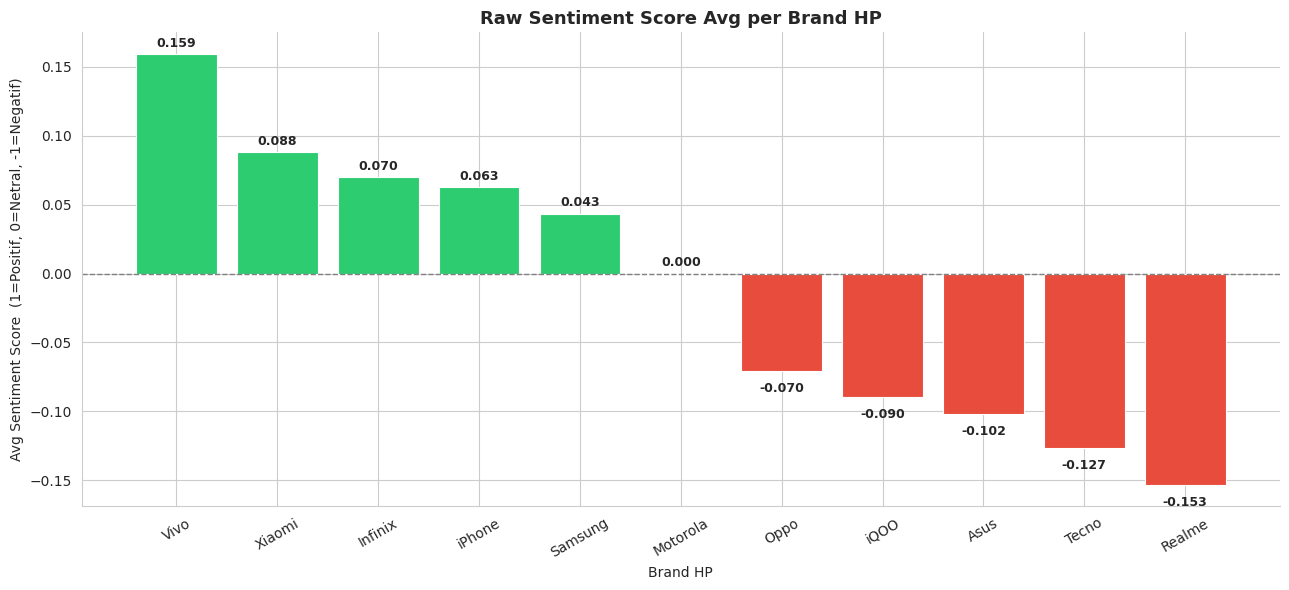

In [8]:
sorted_raw = comparison_table.sort_values('sentiment_score_avg', ascending=False)

colors_raw = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sorted_raw['sentiment_score_avg']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(sorted_raw['Brand'], sorted_raw['sentiment_score_avg'],
              color=colors_raw, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, sorted_raw['sentiment_score_avg']):
    offset = 0.003 if val >= 0 else -0.008
    va = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f"{val:.3f}", ha='center', va=va, fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title("Raw Sentiment Score Avg per Brand HP", fontsize=13, fontweight='bold')
ax.set_xlabel("Brand HP")
ax.set_ylabel("Avg Sentiment Score  (1=Positif, 0=Netral, -1=Negatif)")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## **Chart Weighted Sentiment per Brand HP**


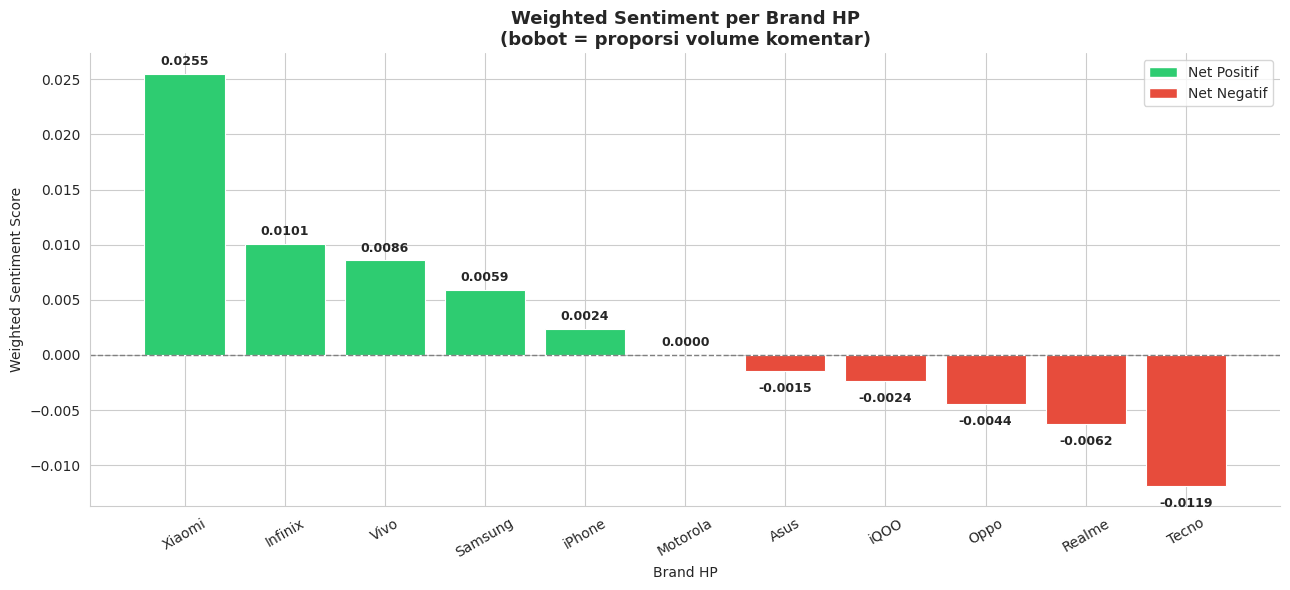

In [10]:
sorted_w = comparison_table.sort_values('weighted_sentiment', ascending=False)

colors_w = ['#2ecc71' if v >= 0 else '#e74c3c' for v in sorted_w['weighted_sentiment']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(sorted_w['Brand'], sorted_w['weighted_sentiment'],
              color=colors_w, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, sorted_w['weighted_sentiment']):
    offset = 0.0005 if val >= 0 else -0.001
    va = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val + offset,
            f"{val:.4f}", ha='center', va=va, fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title("""Weighted Sentiment per Brand HP
(bobot = proporsi volume komentar)""",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Brand HP")
ax.set_ylabel("Weighted Sentiment Score")
ax.tick_params(axis='x', rotation=30)

# legend manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Net Positif'),
                   Patch(facecolor='#e74c3c', label='Net Negatif')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## **Perbandingan Ranking: Raw vs Weighted**

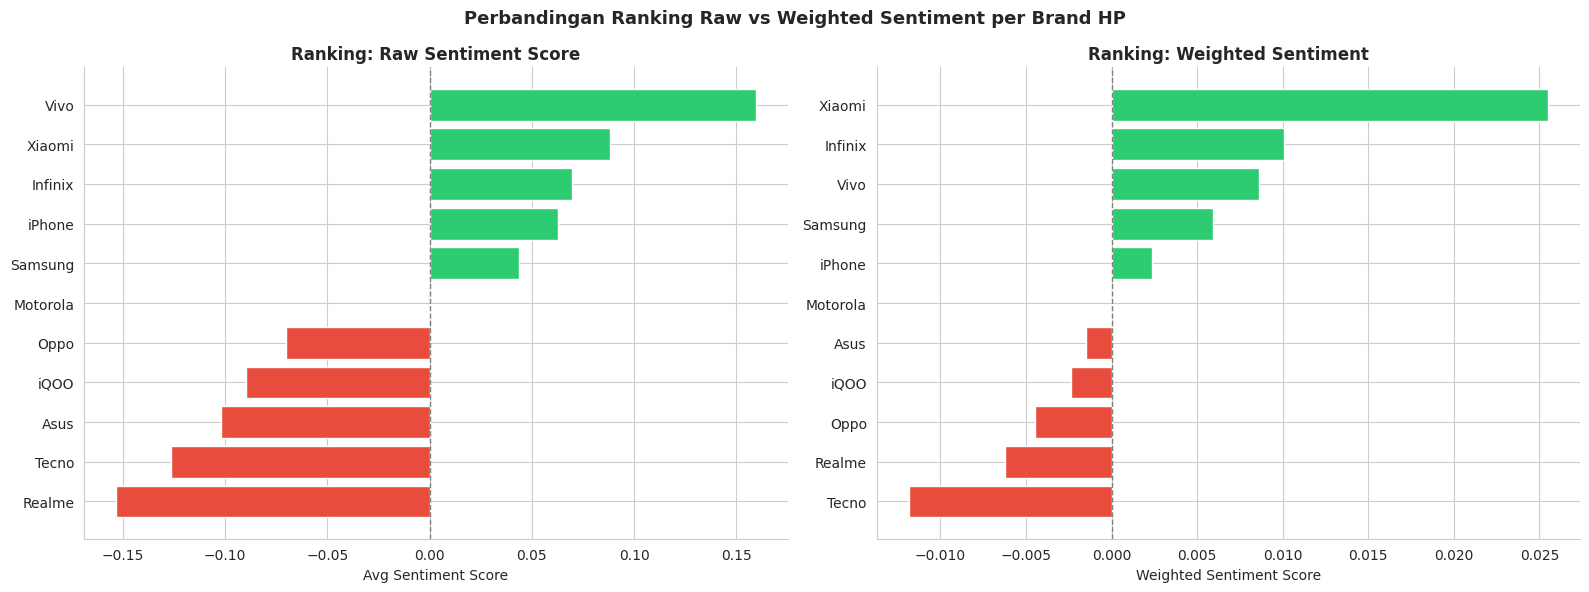

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- raw rank ---
raw_sorted = comparison_table.sort_values('rank_raw')
c_raw = ['#2ecc71' if v >= 0 else '#e74c3c' for v in raw_sorted['sentiment_score_avg']]
axes[0].barh(raw_sorted['Brand'][::-1], raw_sorted['sentiment_score_avg'][::-1],
             color=c_raw[::-1], edgecolor='white')
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title("Ranking: Raw Sentiment Score", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Avg Sentiment Score")

# --- weighted rank ---
w_sorted = comparison_table.sort_values('rank_weighted')
c_w = ['#2ecc71' if v >= 0 else '#e74c3c' for v in w_sorted['weighted_sentiment']]
axes[1].barh(w_sorted['Brand'][::-1], w_sorted['weighted_sentiment'][::-1],
             color=c_w[::-1], edgecolor='white')
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title("Ranking: Weighted Sentiment", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Weighted Sentiment Score")

plt.suptitle("Perbandingan Ranking Raw vs Weighted Sentiment per Brand HP",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **HASIL**

In [17]:
comparison_table.to_csv("perbandingan_hasil_sentiment_analisis_table.csv", index=False)
print("perbandingan_hasil_sentiment_analisis_table.csv")
print()
print(comparison_table.to_string(index=False))

perbandingan_hasil_sentiment_analisis_table.csv

   Brand  jumlah_komentar  sentiment_score_avg  rank_raw  weighted_sentiment  rank_weighted  rank_change
  Xiaomi              976             0.088115         2            0.025504              1            1
 Infinix              487             0.069815         3            0.010083              2            1
    Vivo              182             0.159341         1            0.008600              3           -2
 Samsung              460             0.043478         5            0.005931              4            1
  iPhone              127             0.062992         4            0.002372              5           -1
Motorola              336             0.000000         6            0.000000              6            0
    Asus               49            -0.102041         9           -0.001483              7            2
    iQOO               89            -0.089888         8           -0.002372              8            0
    Op